# CNN Architectures — A Comparative Study

This notebook implements and compares landmark CNN architectures on CIFAR-10:
- AlexNet
- VGG-16
- GoogLeNet / Inception
- ResNet
- Wide ResNet
- DenseNet
- MobileNet
- SENet


## 1. Imports and configuration

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

BATCH_SIZE = 128
NUM_CLASSES = 10
EPOCHS = 25
LR = 0.05


Device: cuda


## 2. CIFAR-10 dataset

In [3]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# Small subsets keep the comparative experiment practical.
train_subset = Subset(trainset, range(5000))
test_subset = Subset(testset, range(1000))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


## 3. AlexNet

A CIFAR-10-adapted AlexNet-style architecture.

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 192, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(192, 384, 3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Dropout(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


## 4. VGG-16

Deep stacks of small 3×3 convolutions.

In [5]:
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(),
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


## 5. GoogLeNet / Inception

The Inception module processes the input through multiple receptive-field sizes in parallel.

In [6]:
class Inception(nn.Module):
    def __init__(self, in_channels, c1, c3red, c3, c5red, c5, pool_proj):
        super().__init__()
        self.b1 = nn.Sequential(nn.Conv2d(in_channels, c1, 1), nn.ReLU())
        self.b2 = nn.Sequential(
            nn.Conv2d(in_channels, c3red, 1), nn.ReLU(),
            nn.Conv2d(c3red, c3, 3, padding=1), nn.ReLU()
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_channels, c5red, 1), nn.ReLU(),
            nn.Conv2d(c5red, c5, 3, padding=1), nn.ReLU(),
            nn.Conv2d(c5, c5, 3, padding=1), nn.ReLU()
        )
        self.b4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, 1), nn.ReLU()
        )

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.inc1 = Inception(64, 32, 32, 64, 8, 16, 16)
        self.inc2 = Inception(128, 64, 48, 96, 12, 24, 24)
        self.pool = nn.MaxPool2d(2)
        self.inc3 = Inception(208, 96, 64, 128, 16, 32, 32)
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(288, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.inc1(x)
        x = self.inc2(x)
        x = self.pool(x)
        x = self.inc3(x)
        x = self.avg(x)
        return self.fc(torch.flatten(x, 1))


## 6. ResNet

### Residual block

The key idea is the shortcut connection:

```text
x ────────────────┐
                  + ── ReLU ──> output
x → Conv → BN → ReLU → Conv → BN ─┘
```

Instead of directly learning H(x), the block learns a residual mapping F(x) and computes H(x) = F(x) + x.

In [7]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 2, 1)
        self.layer2 = self._make_layer(128, 2, 2)
        self.layer3 = self._make_layer(256, 2, 2)
        self.layer4 = self._make_layer(512, 2, 2)
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = [BasicBlock(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn(self.conv(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avg(x)
        return self.fc(torch.flatten(x, 1))


## 7. Wide ResNet

Wide ResNet increases the number of channels instead of making the network extremely deep.

In [8]:
class WideBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride, bias=False) if (stride != 1 or in_channels != out_channels) else nn.Identity()

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return out + self.shortcut(x)

class WideResNet(nn.Module):
    def __init__(self, num_classes=10, k=2):
        super().__init__()
        c1, c2, c3, c4 = 16, 32*k, 64*k, 128*k
        self.conv = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.layer1 = nn.Sequential(WideBlock(c1, c2), WideBlock(c2, c2))
        self.layer2 = nn.Sequential(WideBlock(c2, c3, 2), WideBlock(c3, c3))
        self.layer3 = nn.Sequential(WideBlock(c3, c4, 2), WideBlock(c4, c4))
        self.bn = nn.BatchNorm2d(c4)
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(c4, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avg(F.relu(self.bn(x)))
        return self.fc(torch.flatten(x, 1))


## 8. DenseNet

DenseNet concatenates the outputs of previous layers, encouraging feature reuse.

In [9]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, growth_rate, 3, padding=1, bias=False)
        )

    def forward(self, x):
        return torch.cat([x, self.layer(x)], dim=1)

class DenseBlock(nn.Module):
    def __init__(self, in_channels, num_layers, growth_rate):
        super().__init__()
        layers = []
        channels = in_channels
        for _ in range(num_layers):
            layers.append(DenseLayer(channels, growth_rate))
            channels += growth_rate
        self.block = nn.Sequential(*layers)
        self.out_channels = channels

    def forward(self, x):
        return self.block(x)

class DenseNet(nn.Module):
    def __init__(self, num_classes=10, growth_rate=12):
        super().__init__()
        self.conv = nn.Conv2d(3, 24, 3, padding=1, bias=False)
        self.block1 = DenseBlock(24, 4, growth_rate)
        c1 = self.block1.out_channels
        self.trans1 = nn.Conv2d(c1, c1, 1, bias=False)
        self.block2 = DenseBlock(c1, 4, growth_rate)
        c2 = self.block2.out_channels
        self.trans2 = nn.Conv2d(c2, c2, 1, bias=False)
        self.block3 = DenseBlock(c2, 4, growth_rate)
        c3 = self.block3.out_channels
        self.bn = nn.BatchNorm2d(c3)
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(c3, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.block1(x)
        x = F.avg_pool2d(self.trans1(x), 2)
        x = self.block2(x)
        x = F.avg_pool2d(self.trans2(x), 2)
        x = self.block3(x)
        x = self.avg(F.relu(self.bn(x)))
        return self.fc(torch.flatten(x, 1))


## 9. MobileNet

MobileNet uses depthwise-separable convolution to reduce computation.

In [10]:
class DepthwiseSeparable(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, stride, 1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels), nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

class MobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.features = nn.Sequential(
            DepthwiseSeparable(32, 64),
            DepthwiseSeparable(64, 128, 2),
            DepthwiseSeparable(128, 128),
            DepthwiseSeparable(128, 256, 2),
            DepthwiseSeparable(256, 256),
            DepthwiseSeparable(256, 512, 2),
            DepthwiseSeparable(512, 512),
            DepthwiseSeparable(512, 1024, 2)
        )
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.avg(x)
        return self.fc(torch.flatten(x, 1))


## 10. SENet

Squeeze-and-Excitation recalibrates channel-wise feature responses using global information.

In [11]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden), nn.ReLU(),
            nn.Linear(hidden, channels), nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class SENet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            SEBlock(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(),
            SEBlock(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(),
            SEBlock(256), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(),
            SEBlock(512)
        )
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avg(x)
        return self.fc(torch.flatten(x, 1))


## 11. Shared training utility

In [12]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.05):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)

        test_loss /= len(test_loader.dataset)
        test_acc = correct / total
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Epoch {epoch+1:02d}/{epochs} | train loss {train_loss:.4f} | test loss {test_loss:.4f} | test acc {test_acc:.4f}')

    return history


## 12. Model setup and parameter comparison

In [13]:
model_factories = {
    'AlexNet': AlexNet,
    'VGG-16': VGG16,
    'GoogLeNet': GoogLeNet,
    'ResNet': ResNet,
    'Wide ResNet': WideResNet,
    'DenseNet': DenseNet,
    'MobileNet': MobileNet,
    'SENet': SENet,
}

model_instances = {name: factory() for name, factory in model_factories.items()}

param_counts = {
    name: sum(p.numel() for p in model.parameters())
    for name, model in model_instances.items()
}

for name, count in param_counts.items():
    print(f'{name:12s}: {count:,} parameters')


AlexNet     : 6,976,842 parameters
VGG-16      : 15,245,130 parameters
GoogLeNet   : 232,086 parameters
ResNet      : 11,173,962 parameters
Wide ResNet : 2,748,890 parameters
DenseNet    : 141,058 parameters
MobileNet   : 1,080,138 parameters
SENet       : 1,601,606 parameters


## 13. Train the models

The experiment uses a small CIFAR-10 subset and 10 epochs for demonstration.

In [14]:
models_to_train = {
    'AlexNet': AlexNet(),
    'VGG-16': VGG16(),
    'GoogLeNet': GoogLeNet(),
    'ResNet': ResNet(),
    'Wide ResNet': WideResNet(),
    'DenseNet': DenseNet(),
    'MobileNet': MobileNet(),
    'SENet': SENet(),
}

all_history = {}
trained_models = {}

for name, model in models_to_train.items():
    print('\n' + '=' * 70)
    print(name)
    print('=' * 70)
    start = time.time()
    all_history[name] = train_model(model, train_loader, test_loader, EPOCHS, LR)
    trained_models[name] = model
    print(f'Time: {time.time() - start:.1f}s')



AlexNet
Epoch 01/25 | train loss 2.3020 | test loss 2.2918 | test acc 0.1080
Epoch 02/25 | train loss 2.1986 | test loss 2.1428 | test acc 0.2260
Epoch 03/25 | train loss 2.1052 | test loss 2.0055 | test acc 0.2470
Epoch 04/25 | train loss 1.9722 | test loss 2.0485 | test acc 0.2640
Epoch 05/25 | train loss 1.8978 | test loss 1.9785 | test acc 0.2650
Epoch 06/25 | train loss 1.8317 | test loss 2.3051 | test acc 0.1880
Epoch 07/25 | train loss 1.7979 | test loss 1.8293 | test acc 0.3420
Epoch 08/25 | train loss 1.6748 | test loss 1.8752 | test acc 0.3280
Epoch 09/25 | train loss 1.6937 | test loss 1.5951 | test acc 0.3980
Epoch 10/25 | train loss 1.5959 | test loss 1.4818 | test acc 0.4570
Epoch 11/25 | train loss 1.5535 | test loss 1.6040 | test acc 0.4030
Epoch 12/25 | train loss 1.5453 | test loss 1.5253 | test acc 0.4020
Epoch 13/25 | train loss 1.4430 | test loss 1.5421 | test acc 0.4530
Epoch 14/25 | train loss 1.4475 | test loss 1.5320 | test acc 0.4600
Epoch 15/25 | train loss 

## 14. Learning curves

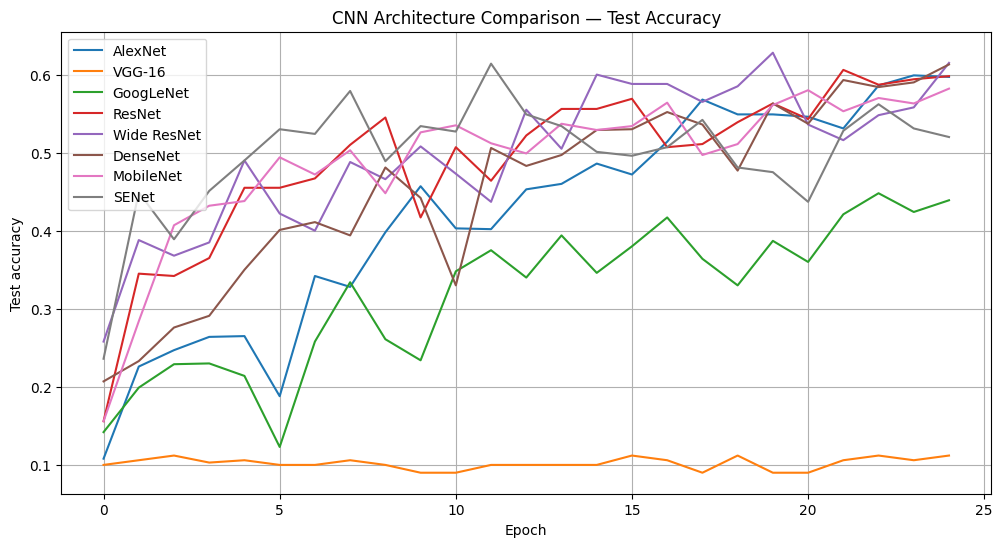

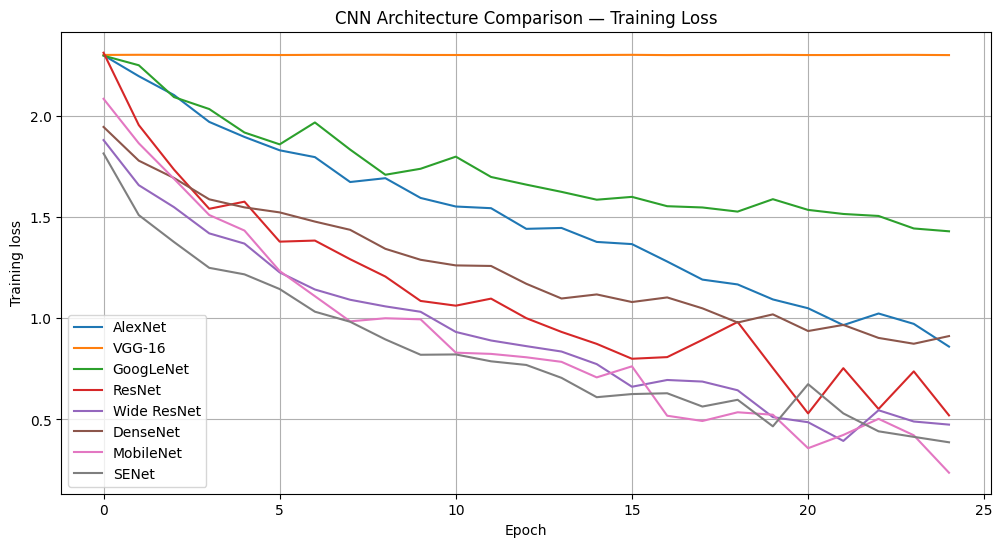

In [15]:
plt.figure(figsize=(12, 6))
for name, history in all_history.items():
    plt.plot(history['test_acc'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('CNN Architecture Comparison — Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for name, history in all_history.items():
    plt.plot(history['train_loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('CNN Architecture Comparison — Training Loss')
plt.legend()
plt.grid(True)
plt.show()


## 15. Final comparison

Wide ResNet  | Params:  2,748,890 | Accuracy: 0.6150 | Loss: 0.4743
DenseNet     | Params:    141,058 | Accuracy: 0.6130 | Loss: 0.9124
ResNet       | Params: 11,173,962 | Accuracy: 0.5980 | Loss: 0.5199
AlexNet      | Params:  6,976,842 | Accuracy: 0.5970 | Loss: 0.8603
MobileNet    | Params:  1,080,138 | Accuracy: 0.5820 | Loss: 0.2362
SENet        | Params:  1,601,606 | Accuracy: 0.5200 | Loss: 0.3867
GoogLeNet    | Params:    232,086 | Accuracy: 0.4390 | Loss: 1.4309
VGG-16       | Params: 15,245,130 | Accuracy: 0.1120 | Loss: 2.3029


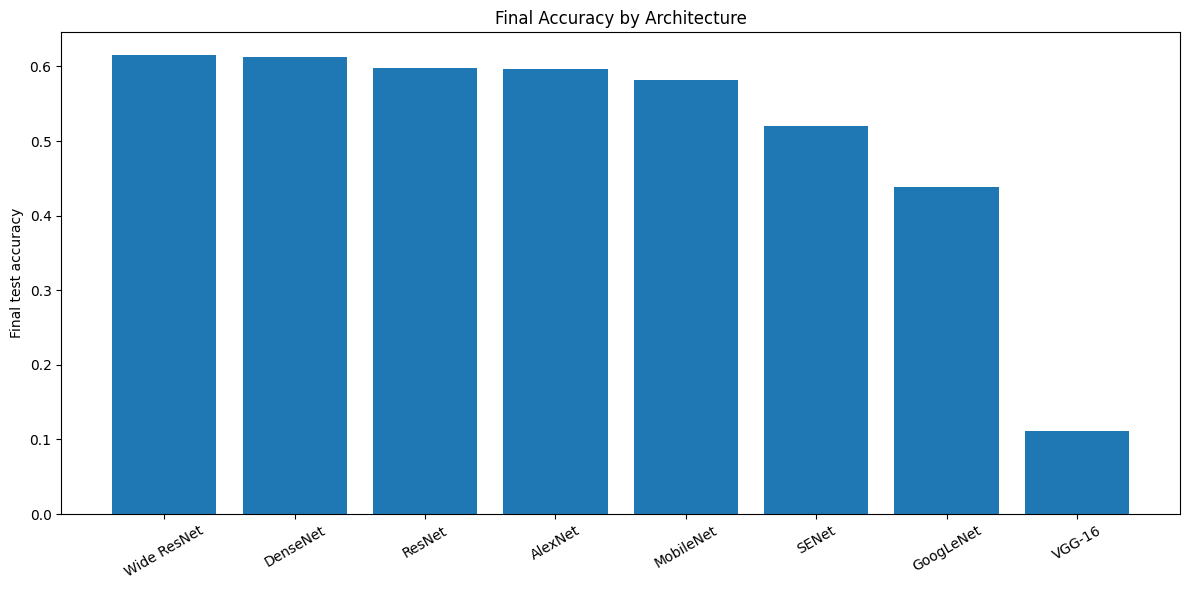

In [16]:
results = []
for name, history in all_history.items():
    results.append({
        'Model': name,
        'Parameters': param_counts[name],
        'Final Accuracy': history['test_acc'][-1],
        'Final Train Loss': history['train_loss'][-1],
    })

results = sorted(results, key=lambda x: x['Final Accuracy'], reverse=True)

for row in results:
    print(f"{row['Model']:12s} | Params: {row['Parameters']:>10,} | Accuracy: {row['Final Accuracy']:.4f} | Loss: {row['Final Train Loss']:.4f}")

names = [r['Model'] for r in results]
accuracies = [r['Final Accuracy'] for r in results]

plt.figure(figsize=(12, 6))
plt.bar(names, accuracies)
plt.ylabel('Final test accuracy')
plt.title('Final Accuracy by Architecture')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 16. CNN architecture timeline

| Architecture | Year | Main contribution |
|---|---:|---|
| AlexNet | 2012 | Deep CNN + ReLU + GPU training |
| VGG | 2014 | Very deep stacks of 3×3 convolutions |
| GoogLeNet | 2014 | Inception multi-branch module |
| ResNet | 2015 | Residual / skip connections |
| Wide ResNet | 2016 | Wider residual blocks |
| DenseNet | 2017 | Dense feature connectivity |
| SENet | 2017 | Channel attention / recalibration |
| MobileNet | 2017 | Depthwise-separable convolutions |


## 17. First-layer filter visualization

This visualization uses the **trained models** so that the displayed filters are learned rather than random initializations.

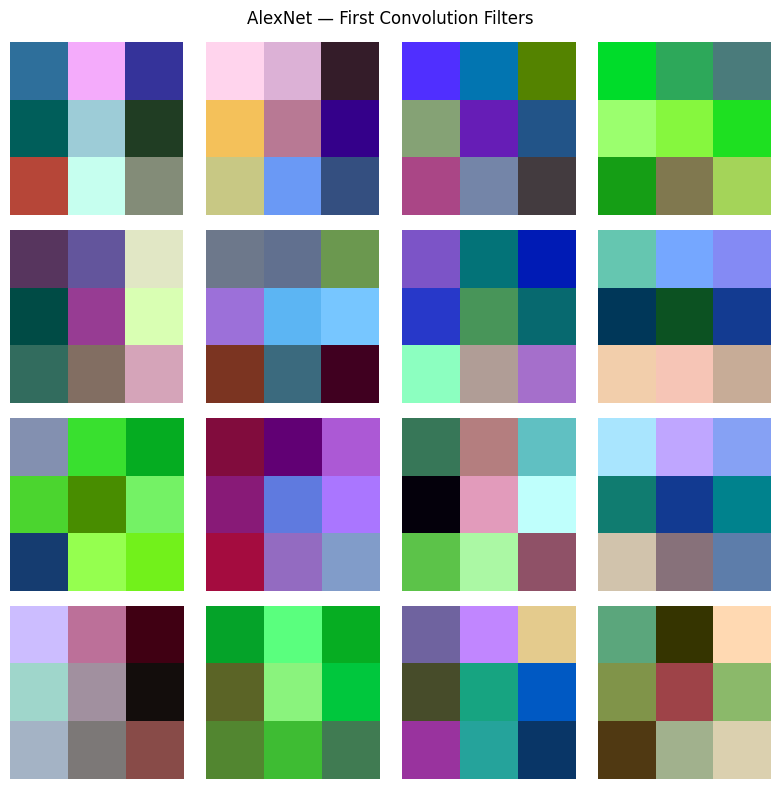

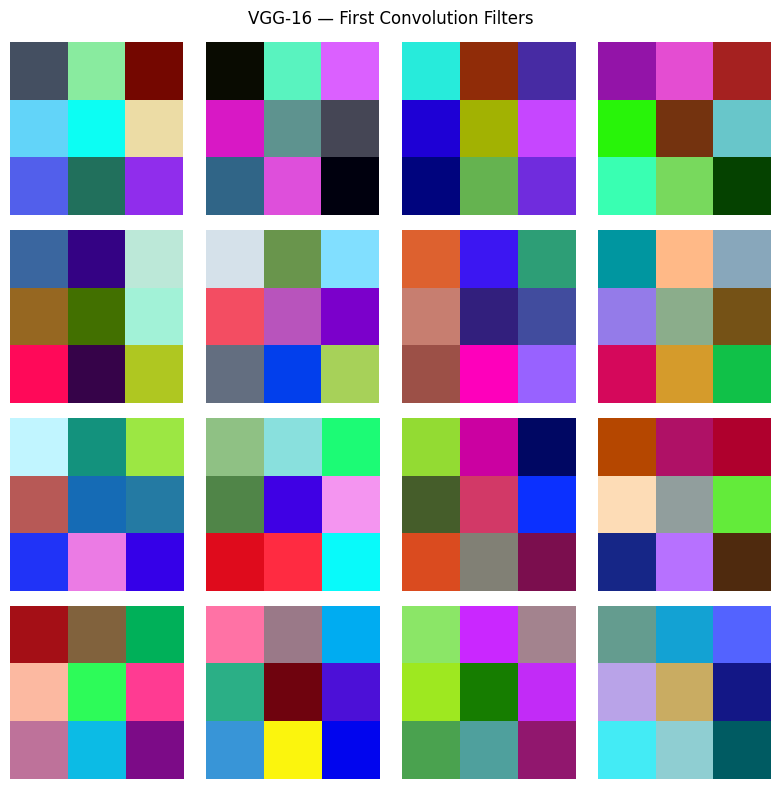

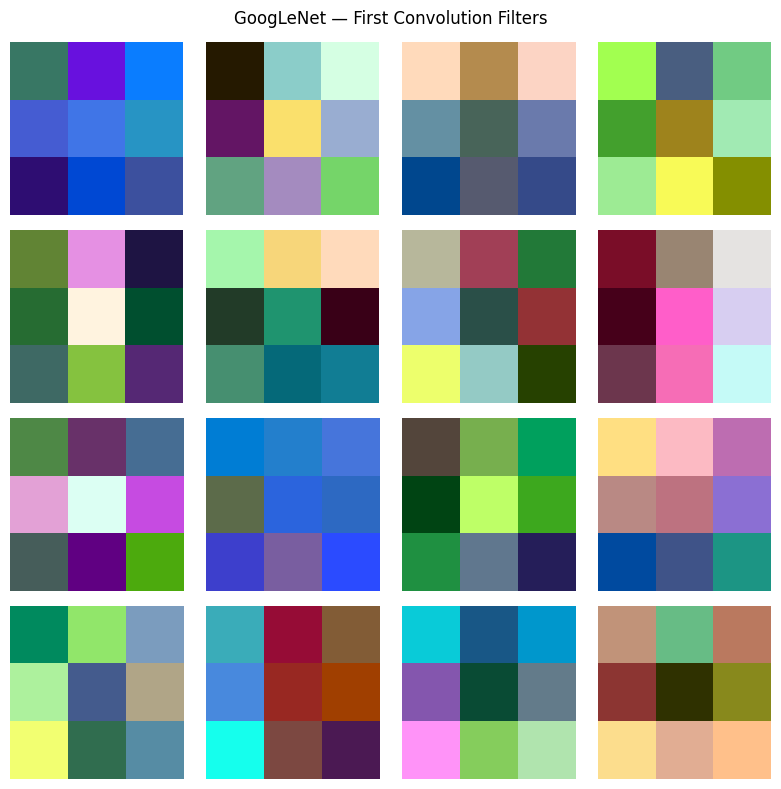

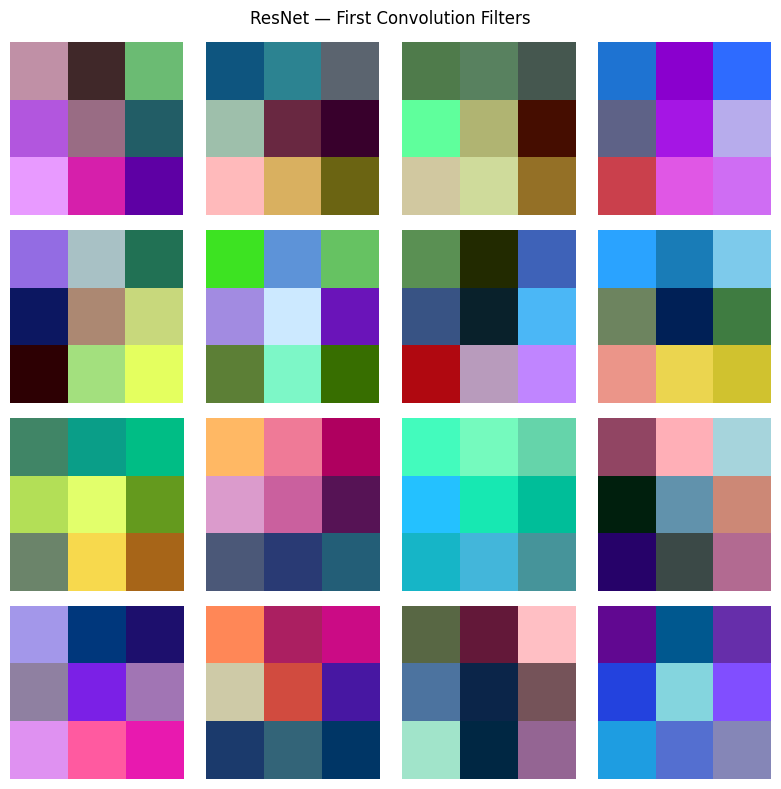

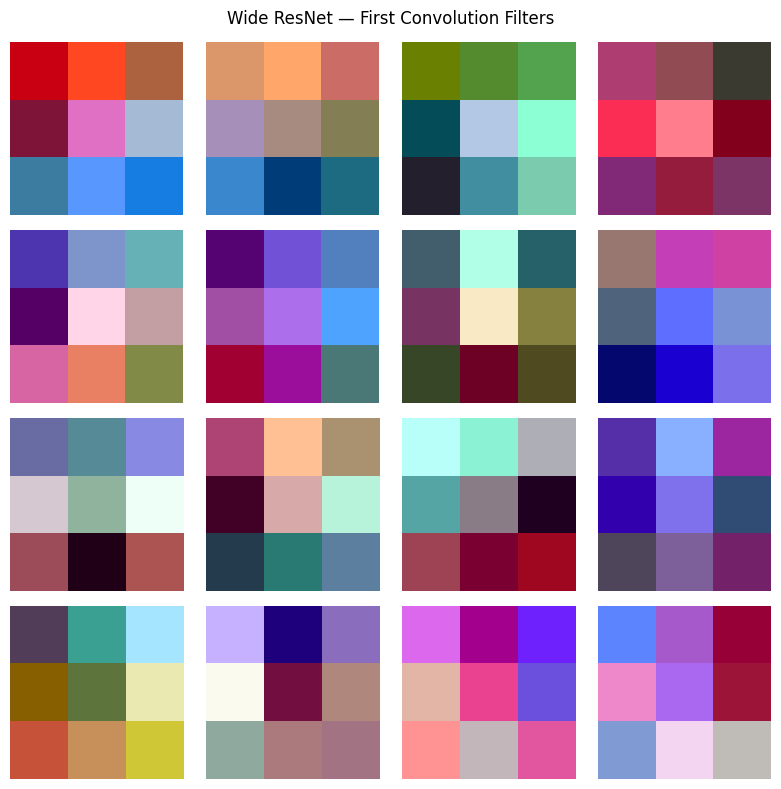

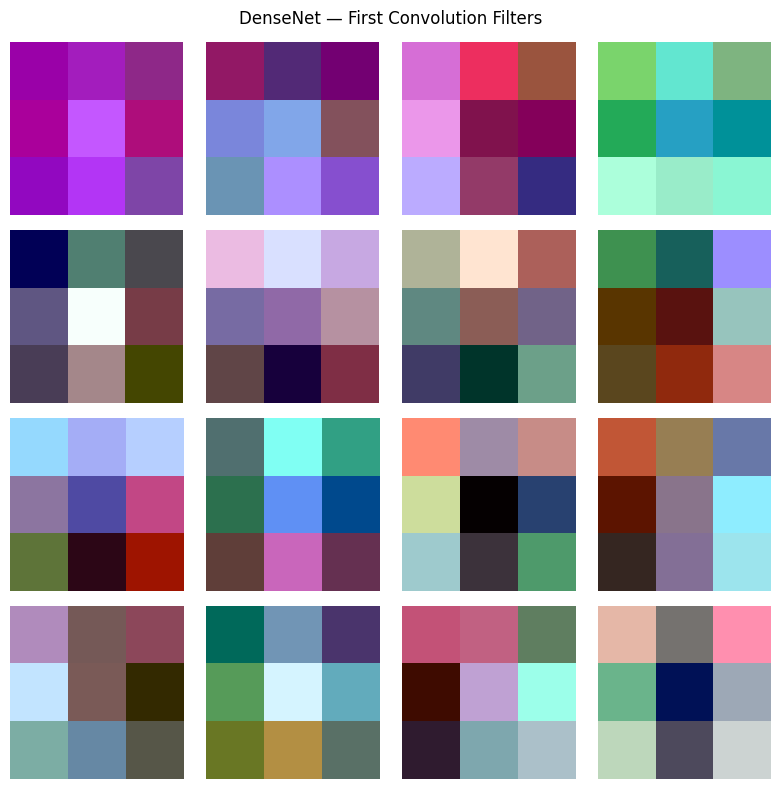

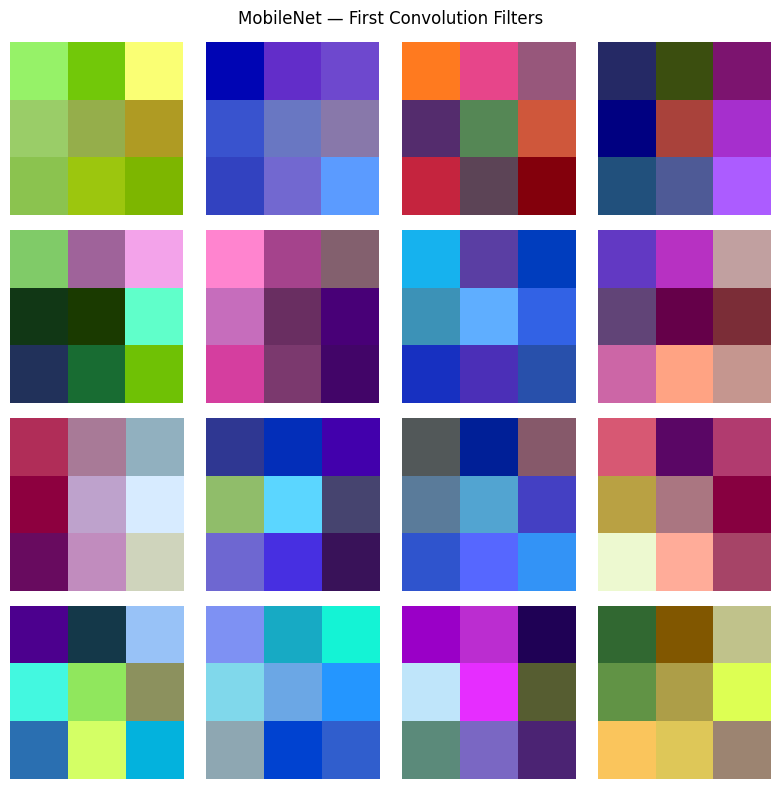

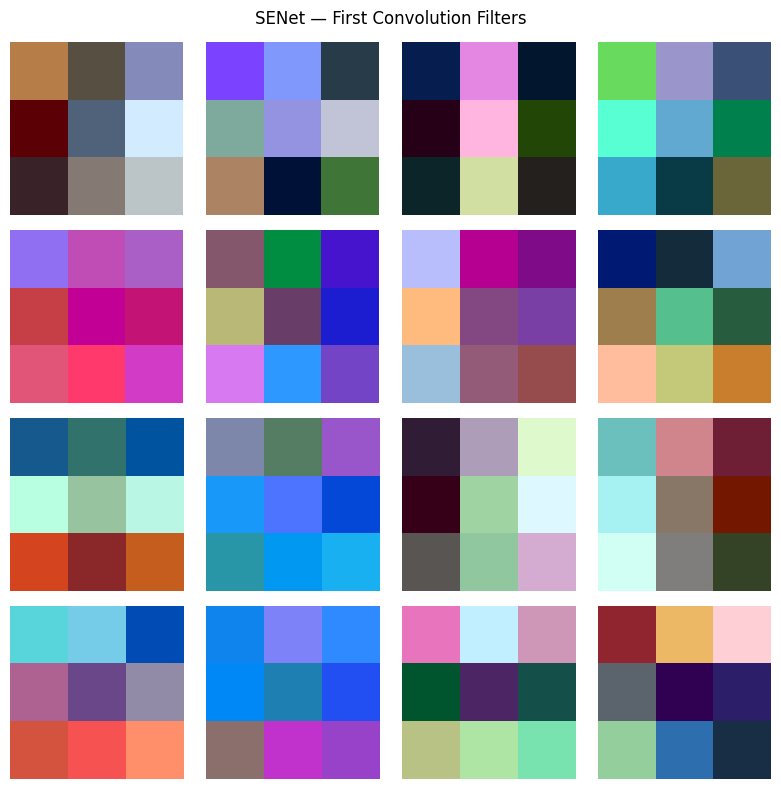

In [17]:
def first_conv_layer(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            return module
    return None

for name, model in trained_models.items():
    conv = first_conv_layer(model)
    if conv is None:
        continue

    weights = conv.weight.detach().cpu()
    n = min(16, weights.shape[0])

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(f'{name} — First Convolution Filters')

    for i, ax in enumerate(axes.flat):
        if i < n:
            w = weights[i]
            if w.shape[0] == 3:
                w = w.permute(1, 2, 0)
                w = (w - w.min()) / (w.max() - w.min() + 1e-8)
                ax.imshow(w)
            else:
                ax.imshow(w[0], cmap='gray')
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
